# CMPS 460 Machine Learning Project: TCGA-CHOL Cancer Classification

### Students: Islam AL-Absi 202209546, Mohamad Allouh 201904335

This notebook completes the full CMPS 460 machine learning lifecycle for the assigned Group 25, using the dataset 2 TCGA-CHOL gene expression dataset.

**Goal:** classify each biological sample as `0 = Healthy/Normal` or `1 = Tumor/Cancerous`.

**Project context** rows are samples/patients/tissue biopsies, columns are genes/features, and values are RNA-seq gene expression reads. The label file provides the binary target.

**Files used:**

- `data/G2-TCGA-CHOL_EX.csv`
- `data/G2-TCGA-CHOL_Label.csv`


## 1. Setup

TensorFlow/Keras is attempted for the deep learning model. If it is not installed, the notebook automatically uses `sklearn.neural_network.MLPClassifier` as the fallback neural network.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", context="notebook")

DATA_DIR = Path("data")
EX_PATH = DATA_DIR / "G2-TCGA-CHOL_EX.csv"
LABEL_PATH = DATA_DIR / "G2-TCGA-CHOL_Label.csv"

OUTPUT_DIR = Path("outputs")
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", Path.cwd())
print("Feature file exists:", EX_PATH.exists())
print("Label file exists:", LABEL_PATH.exists())

Working directory: c:\Users\ialab\Desktop\Machine Learning\project\cmps460_g2_chol_project\ML_Project
Feature file exists: True
Label file exists: True


## 2. Dataset Loading and Header Check

The CSV files are checked before loading. If the first row is numeric, the file is treated as headerless. This avoids accidentally using the first sample as column names.

In [2]:
def first_row_is_numeric(path, max_tokens=100):
    with Path(path).open("r", encoding="utf-8", errors="replace") as file:
        first_line = file.readline().strip()
    tokens = first_line.split(",")[:max_tokens]
    if not tokens or tokens == [""]:
        return False
    for token in tokens:
        try:
            float(token.strip().strip('"'))
        except ValueError:
            return False
    return True


feature_headerless = first_row_is_numeric(EX_PATH)
label_headerless = first_row_is_numeric(LABEL_PATH)
feature_header = None if feature_headerless else 0
label_header = None if label_headerless else 0

print("Feature file appears headerless:", feature_headerless)
print("Label file appears headerless:", label_headerless)

X = pd.read_csv(EX_PATH, header=feature_header)
y_raw = pd.read_csv(LABEL_PATH, header=label_header)

if feature_header is None:
    X.columns = [f"gene_{i}" for i in range(X.shape[1])]
else:
    X.columns = [str(col) for col in X.columns]

X = X.apply(pd.to_numeric, errors="coerce")
y = pd.to_numeric(y_raw.iloc[:, 0], errors="raise").astype(int)
y.name = "target"

if len(X) != len(y):
    raise ValueError(f"Feature rows ({len(X)}) and labels ({len(y)}) are not aligned.")

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

class_distribution = (
    y.value_counts()
    .sort_index()
    .rename(index={0: "Healthy/Normal (0)", 1: "Tumor/Cancerous (1)"})
    .to_frame("sample_count")
)
class_distribution["percentage"] = (class_distribution["sample_count"] / len(y) * 100).round(2)

print("Dataset shape:", X.shape)
print("Label shape:", y.shape)
print("Sample count:", X.shape[0])
print("Feature count:", X.shape[1])
print("Target name:", y.name)
display(class_distribution)
display(pd.concat([X.iloc[:, :5], y], axis=1).head())

Feature file appears headerless: True
Label file appears headerless: True
Dataset shape: (44, 43697)
Label shape: (44,)
Sample count: 44
Feature count: 43697
Target name: target


,sample_count,percentage
target,,
Healthy/Normal (0),9,20.45
Tumor/Cancerous (1),35,79.55


,gene_0,gene_1,gene_2,gene_3,gene_4,target
0,6289,1,1398,655,140,0
1,7433,0,1565,794,124,0
2,4902,0,1623,666,148,0
3,5610,9,1388,766,170,0
4,7037,1,1365,675,166,0


**Loading observation:** The provided files are numeric and headerless. The aligned dataset contains 44 samples and 43,697 gene features. Because there are far more features than samples, feature selection is required.

## 3. Exploratory Data Analysis

EDA checks structure, class balance, missing values, duplicates, expression ranges, selected gene distributions, and feature relevance.

In [3]:
eda_overview = pd.DataFrame({
    "Metric": [
        "Number of samples",
        "Number of genes/features",
        "Missing feature values",
        "Missing target values",
        "Duplicate samples",
        "Healthy/Normal samples (0)",
        "Tumor/Cancerous samples (1)",
    ],
    "Value": [
        X.shape[0],
        X.shape[1],
        int(X.isna().sum().sum()),
        int(y.isna().sum()),
        int(X.duplicated().sum()),
        int((y == 0).sum()),
        int((y == 1).sum()),
    ],
})
eda_overview.to_csv(TABLES_DIR / "eda_overview.csv", index=False)
display(eda_overview)

,Metric,Value
0,Number of samples,44
1,Number of genes/features,43697
2,Missing feature values,0
3,Missing target values,0
4,Duplicate samples,0
5,Healthy/Normal samples (0),9
6,Tumor/Cancerous samples (1),35


### 3.1 Class Distribution

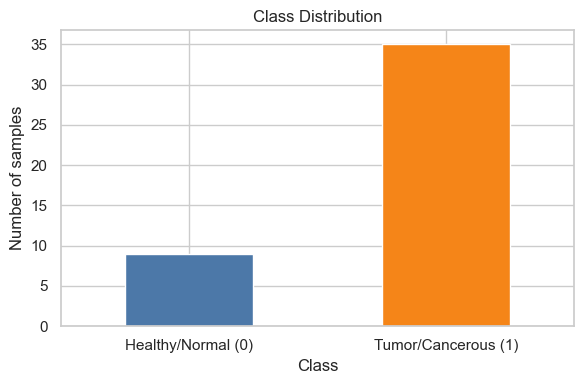

,sample_count,percentage
target,,
Healthy/Normal (0),9,20.45
Tumor/Cancerous (1),35,79.55


In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
class_distribution["sample_count"].plot(kind="bar", color=["#4C78A8", "#F58518"], ax=ax)
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
ax.tick_params(axis="x", rotation=0)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

display(class_distribution)

**Observation:** The classes are imbalanced, with tumor/cancerous samples as the majority class. Stratified splitting, class weighting, and metrics such as precision, recall, F1-score, and ROC-AUC are more meaningful than accuracy alone.

### 3.2 Missing Values and Duplicate Samples

In [5]:
missing_summary = pd.DataFrame({
    "total_missing_values": [int(X.isna().sum().sum())],
    "features_with_missing_values": [int((X.isna().sum() > 0).sum())],
    "samples_with_missing_values": [int(X.isna().any(axis=1).sum())],
    "duplicate_samples": [int(X.duplicated().sum())],
})
missing_summary.to_csv(TABLES_DIR / "missing_duplicate_summary.csv", index=False)
display(missing_summary)

if missing_summary.loc[0, "total_missing_values"] == 0:
    print("No missing gene expression values were found.")
else:
    display(X.isna().sum().sort_values(ascending=False).head(10).to_frame("missing_count"))

print("Duplicate sample rows:", int(X.duplicated().sum()))

,total_missing_values,features_with_missing_values,samples_with_missing_values,duplicate_samples
0,0,0,0,0


No missing gene expression values were found.


Duplicate sample rows: 0


**Observation:** This dataset has no missing values and no duplicate sample rows. The modeling pipelines still include median imputation so the workflow remains robust and leakage-safe.

### 3.3 Gene Expression Statistics and Ranges

,expression
count,1.922668e+06
mean,1.700395e+03
std,3.377175e+04
min,0.000000e+00
1%,0.000000e+00
5%,0.000000e+00
25%,0.000000e+00
50%,4.000000e+00
75%,2.300000e+02
95%,4.386000e+03


,total_expression_per_sample
count,4.400000e+01
mean,7.430218e+07
std,2.281550e+02
min,7.430168e+07
25%,7.430207e+07
50%,7.430221e+07
75%,7.430235e+07
max,7.430263e+07


,mean_expression_per_gene
count,4.369700e+04
mean,1.700395e+03
std,2.419928e+04
min,2.272727e-02
25%,4.545455e-01
50%,8.022727e+00
75%,3.378636e+02
max,2.770574e+06


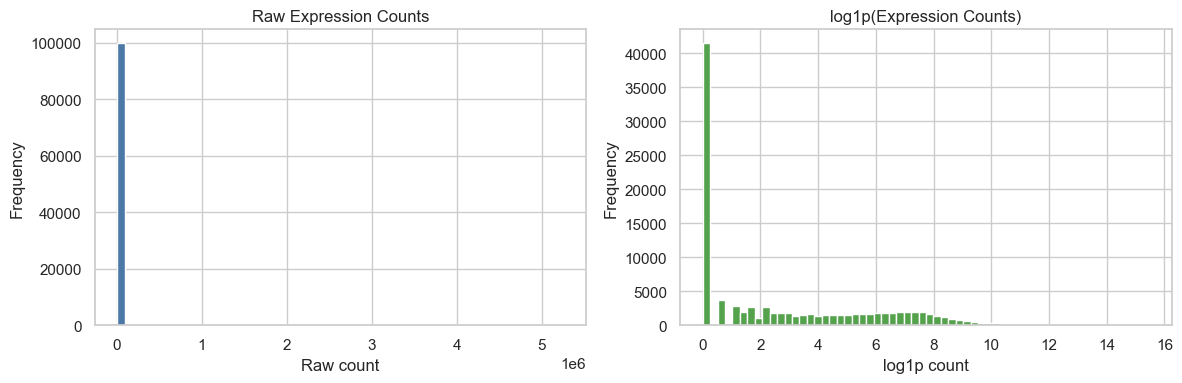

In [6]:
expression_values = X.to_numpy(dtype=float).ravel()
expression_stats = pd.Series(expression_values, name="expression").describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).to_frame()
sample_total_stats = X.sum(axis=1).describe().to_frame("total_expression_per_sample")
gene_mean_stats = X.mean(axis=0).describe().to_frame("mean_expression_per_gene")

expression_stats.to_csv(TABLES_DIR / "expression_value_statistics.csv")
sample_total_stats.to_csv(TABLES_DIR / "sample_total_expression_statistics.csv")
gene_mean_stats.to_csv(TABLES_DIR / "gene_mean_expression_statistics.csv")

display(expression_stats)
display(sample_total_stats)
display(gene_mean_stats)

rng = np.random.default_rng(RANDOM_STATE)
sampled_values = rng.choice(expression_values, size=min(100_000, expression_values.size), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sampled_values, bins=60, color="#4C78A8")
axes[0].set_title("Raw Expression Counts")
axes[0].set_xlabel("Raw count")
axes[0].set_ylabel("Frequency")
axes[1].hist(np.log1p(sampled_values), bins=60, color="#54A24B")
axes[1].set_title("log1p(Expression Counts)")
axes[1].set_xlabel("log1p count")
axes[1].set_ylabel("Frequency")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "expression_range_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Raw RNA-seq counts are highly right-skewed. The `log1p` transform compresses extreme values while preserving zeros, so it is used during preprocessing.

### 3.4 Sample-Level Expression by Class

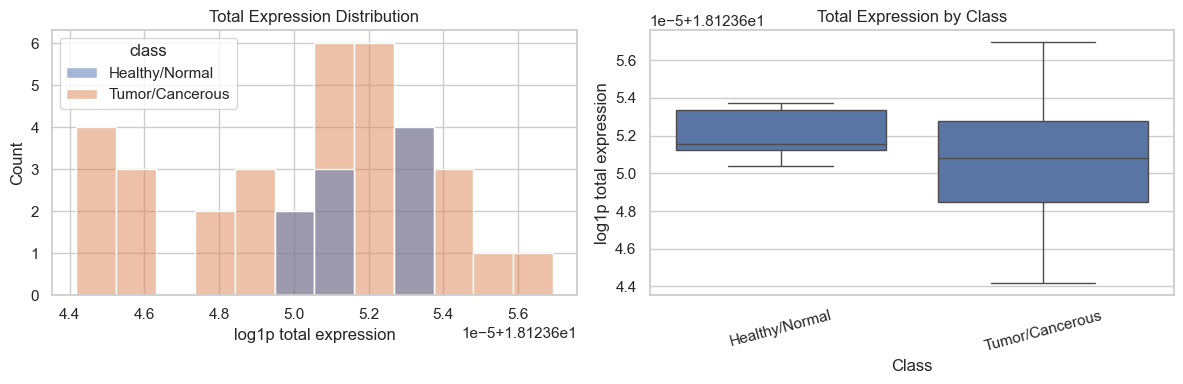

,count,mean,std,min,25%,50%,75%,max
class,,,,,,,,
Healthy/Normal,9.0,7.430227e+07,97.122918,74302145.0,74302208.0,74302232.0,74302365.0,74302391.0
Tumor/Cancerous,35.0,7.430215e+07,246.337976,74301683.0,74302003.5,74302176.0,74302322.0,74302631.0


In [7]:
sample_expression_df = pd.DataFrame({
    "total_expression": X.sum(axis=1),
    "log1p_total_expression": np.log1p(X.sum(axis=1)),
    "class": y.map({0: "Healthy/Normal", 1: "Tumor/Cancerous"}),
})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data=sample_expression_df, x="log1p_total_expression", hue="class", bins=12, ax=axes[0])
axes[0].set_title("Total Expression Distribution")
axes[0].set_xlabel("log1p total expression")
sns.boxplot(data=sample_expression_df, x="class", y="log1p_total_expression", ax=axes[1])
axes[1].set_title("Total Expression by Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("log1p total expression")
axes[1].tick_params(axis="x", rotation=15)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "sample_total_expression_by_class.png", dpi=150, bbox_inches="tight")
plt.show()

display(sample_expression_df.groupby("class")["total_expression"].describe())

**Observation:** Sample-level total expression is useful for detecting unusual samples, but classification should use selected gene-level features rather than only total read count.

### 3.5 Selected Gene Distributions

,variance
gene_4801,6.228305e+12
gene_10873,4.064563e+12
gene_17044,1.940541e+12
gene_12800,1.771721e+12
gene_4383,1.125097e+12
gene_18505,1.046220e+12
gene_17093,1.038462e+12
gene_17011,7.016062e+11
gene_9023,6.167768e+11
gene_4653,3.678105e+11


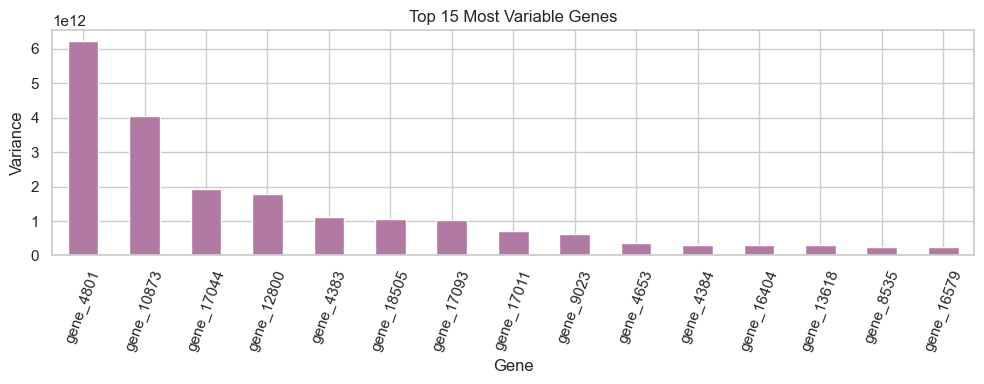

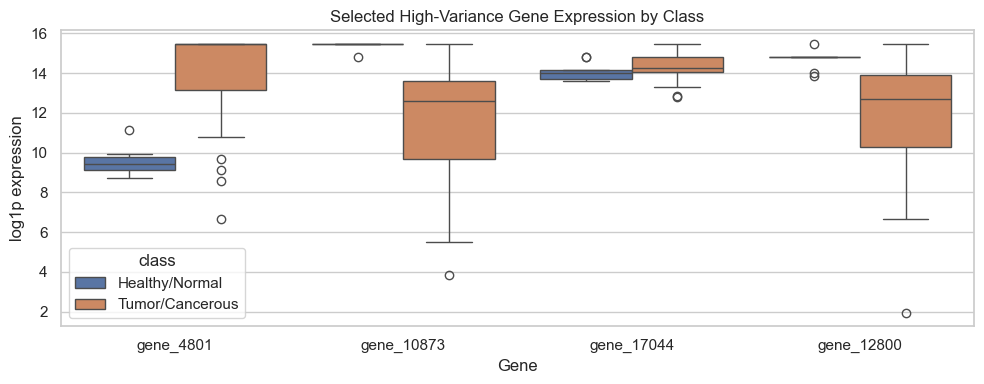

In [8]:
gene_variance = X.var(axis=0).sort_values(ascending=False)
top_variable_genes = gene_variance.head(20).to_frame("variance")
top_variable_genes.to_csv(TABLES_DIR / "top_variable_genes.csv")
display(top_variable_genes.head(10))

fig, ax = plt.subplots(figsize=(10, 4))
top_variable_genes.head(15)["variance"].plot(kind="bar", color="#B279A2", ax=ax)
ax.set_title("Top 15 Most Variable Genes")
ax.set_xlabel("Gene")
ax.set_ylabel("Variance")
ax.tick_params(axis="x", rotation=70)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "top_variable_genes.png", dpi=150, bbox_inches="tight")
plt.show()

selected_genes = top_variable_genes.index[:4].tolist()
plot_df = X[selected_genes].copy()
plot_df["class"] = y.map({0: "Healthy/Normal", 1: "Tumor/Cancerous"})
long_df = plot_df.melt(id_vars="class", var_name="gene", value_name="expression")
long_df["log1p_expression"] = np.log1p(long_df["expression"])

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=long_df, x="gene", y="log1p_expression", hue="class", ax=ax)
ax.set_title("Selected High-Variance Gene Expression by Class")
ax.set_xlabel("Gene")
ax.set_ylabel("log1p expression")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "selected_gene_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Some high-variance genes show different expression ranges by class, but single genes are noisy. This supports using feature selection and multivariate models.

### 3.6 Correlation and Feature Relevance Analysis

,gene,target_correlation,absolute_correlation
25823,gene_25823,-0.993773,0.993773
35953,gene_35953,-0.987728,0.987728
31190,gene_31190,-0.981454,0.981454
43153,gene_43153,-0.976440,0.976440
23754,gene_23754,-0.974229,0.974229
31340,gene_31340,-0.972905,0.972905
30069,gene_30069,-0.972271,0.972271
24850,gene_24850,-0.968993,0.968993
20802,gene_20802,-0.966823,0.966823
36224,gene_36224,-0.963952,0.963952


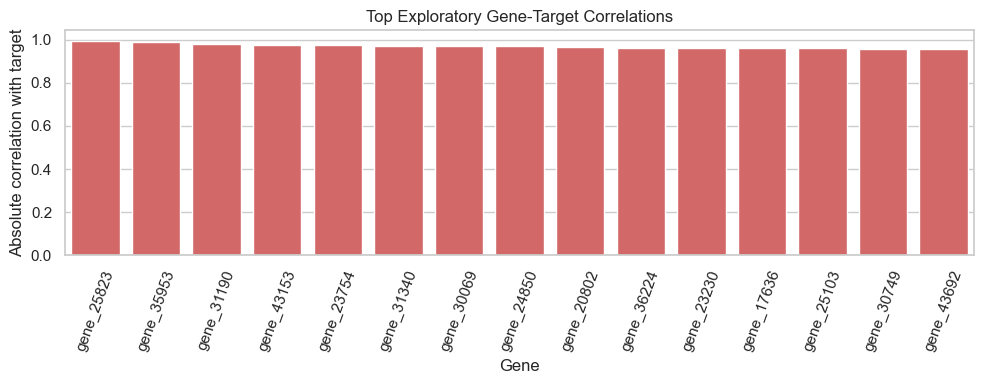

In [9]:
log_X = np.log1p(X.to_numpy(dtype=float))
target_array = y.to_numpy(dtype=float)

target_centered = target_array - target_array.mean()
features_centered = log_X - log_X.mean(axis=0)
numerator = np.sum(features_centered * target_centered[:, None], axis=0)
denominator = np.sqrt(np.sum(features_centered ** 2, axis=0) * np.sum(target_centered ** 2))
correlations = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator != 0)

relevance_df = pd.DataFrame({
    "gene": X.columns,
    "target_correlation": correlations,
    "absolute_correlation": np.abs(correlations),
}).sort_values("absolute_correlation", ascending=False)
relevance_df.head(20).to_csv(TABLES_DIR / "top_target_correlated_genes.csv", index=False)
display(relevance_df.head(15))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=relevance_df.head(15), x="gene", y="absolute_correlation", color="#E45756", ax=ax)
ax.set_title("Top Exploratory Gene-Target Correlations")
ax.set_xlabel("Gene")
ax.set_ylabel("Absolute correlation with target")
ax.tick_params(axis="x", rotation=70)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "top_gene_target_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** The strongest exploratory correlations suggest that a smaller subset of genes contains useful class signal. This ranking is for EDA only. Final feature selection is fit only on training data inside pipelines to avoid leakage.

## 4. Data Cleaning and Preprocessing

Preprocessing is leakage-safe:

- Duplicate handling occurs before splitting.
- Missing values are imputed inside each pipeline.
- `log1p`, `StandardScaler`, and `SelectKBest` are fit only on training data.
- The train/test split uses `stratify=y`.
- Outliers are discussed rather than removed automatically, because extreme RNA-seq values may be real biological signals.

In [10]:
X_model = X.copy()
y_model = y.copy()

duplicate_mask = X_model.duplicated()
if duplicate_mask.any():
    X_model = X_model.loc[~duplicate_mask].reset_index(drop=True)
    y_model = y_model.loc[~duplicate_mask].reset_index(drop=True)

sample_totals = X_model.sum(axis=1)
q1, q3 = sample_totals.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_count = int(((sample_totals < q1 - 1.5 * iqr) | (sample_totals > q3 + 1.5 * iqr)).sum())

cleaning_summary = pd.DataFrame({
    "item": [
        "samples_after_duplicate_handling",
        "features_after_duplicate_handling",
        "missing_values_before_pipeline_imputation",
        "sample_total_expression_outliers_by_iqr_rule",
    ],
    "value": [X_model.shape[0], X_model.shape[1], int(X_model.isna().sum().sum()), outlier_count],
})
cleaning_summary.to_csv(TABLES_DIR / "cleaning_summary.csv", index=False)
display(cleaning_summary)

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_model,
)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "samples": [X_train.shape[0], X_test.shape[0]],
    "features": [X_train.shape[1], X_test.shape[1]],
    "healthy_normal_0": [int((y_train == 0).sum()), int((y_test == 0).sum())],
    "tumor_cancerous_1": [int((y_train == 1).sum()), int((y_test == 1).sum())],
})
split_summary.to_csv(TABLES_DIR / "train_test_split_summary.csv", index=False)
display(split_summary)

,item,value
0,samples_after_duplicate_handling,44
1,features_after_duplicate_handling,43697
2,missing_values_before_pipeline_imputation,0
3,sample_total_expression_outliers_by_iqr_rule,0


,split,samples,features,healthy_normal_0,tumor_cancerous_1
0,train,33,43697,7,26
1,test,11,43697,2,9


In [11]:
K_BASELINE = min(500, X_train.shape[1])
POSSIBLE_K_VALUES = sorted(set([k for k in [50, 100, 500, 1000] if k <= X_train.shape[1]] + [K_BASELINE]))

train_class_counts = y_train.value_counts().sort_index()
imbalance_ratio = train_class_counts.max() / train_class_counts.min()
CLASS_WEIGHT = "balanced" if imbalance_ratio >= 1.5 else None

print("Baseline selected features:", K_BASELINE)
print("Feature-selection k values for tuning:", POSSIBLE_K_VALUES)
print("Training class counts:", train_class_counts.to_dict())
print("Imbalance ratio:", round(float(imbalance_ratio), 3))
print("Class weight setting:", CLASS_WEIGHT)

def make_preprocessing_steps(k=K_BASELINE):
    return [
        ("imputer", SimpleImputer(strategy="median")),
        ("log_transform", FunctionTransformer(np.log1p, validate=False)),
        ("variance", VarianceThreshold()),
        ("scaler", StandardScaler()),
        ("select", SelectKBest(score_func=f_classif, k=k)),
    ]

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

Baseline selected features: 500
Feature-selection k values for tuning: [50, 100, 500, 1000]
Training class counts: {0: 7, 1: 26}
Imbalance ratio: 3.714
Class weight setting: balanced


## 5. Model Evaluation Helper

Each model is evaluated with accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and classification report.

In [12]:
all_results = []
fitted_models = {}
CLASS_LABELS = ["Healthy/Normal", "Tumor/Cancerous"]


def safe_filename(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", text).strip("_").lower()


def metric_row(name, phase, category, y_true, y_pred, y_score=None):
    return {
        "Phase": phase,
        "Category": category,
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score) if y_score is not None and len(np.unique(y_true)) == 2 else np.nan,
    }


def show_evaluation(name, phase, category, y_true, y_pred, y_score=None):
    row = metric_row(name, phase, category, y_true, y_pred, y_score)
    all_results.append(row)
    print(f"=== {phase}: {name} ===")
    print(pd.Series(row).drop(labels=["Phase", "Category", "Model"]))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=CLASS_LABELS, zero_division=0))

    fig, ax = plt.subplots(figsize=(4.8, 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=CLASS_LABELS, cmap="Blues", colorbar=False, ax=ax)
    ax.set_title(f"Confusion Matrix: {name}")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"confusion_matrix_{safe_filename(phase + '_' + name)}.png", dpi=150, bbox_inches="tight")
    plt.show()

    if y_score is not None and len(np.unique(y_true)) == 2:
        fig, ax = plt.subplots(figsize=(5, 4))
        RocCurveDisplay.from_predictions(y_true, y_score, ax=ax)
        ax.set_title(f"ROC Curve: {name}")
        fig.tight_layout()
        fig.savefig(FIGURES_DIR / f"roc_curve_{safe_filename(phase + '_' + name)}.png", dpi=150, bbox_inches="tight")
        plt.show()
    return row


def evaluate_sklearn_model(name, model, phase, category, already_fit=False):
    if not already_fit:
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None
    fitted_models[name] = model
    return show_evaluation(name, phase, category, y_test, y_pred, y_score)

## 6. Baseline Models

Three model categories are trained: Logistic Regression, Random Forest, and a neural network.

### 6.1 Traditional ML: Logistic Regression

Logistic Regression is a strong high-dimensional binary classification baseline. It is regularized, fast, interpretable, and works well with scaled features. Class weighting handles the imbalance.

=== Baseline: Logistic Regression ===
Accuracy     1.0
Precision    1.0
Recall       1.0
F1-score     1.0
ROC-AUC      1.0
dtype: object

Classification report:
                 precision    recall  f1-score   support

 Healthy/Normal       1.00      1.00      1.00         2
Tumor/Cancerous       1.00      1.00      1.00         9

       accuracy                           1.00        11
      macro avg       1.00      1.00      1.00        11
   weighted avg       1.00      1.00      1.00        11



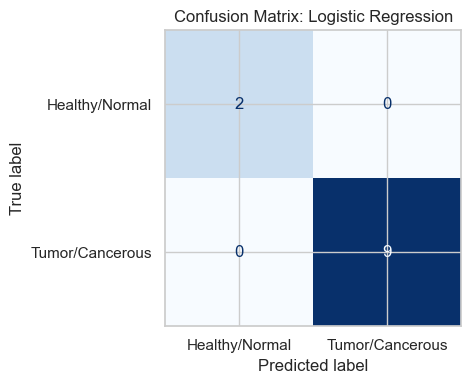

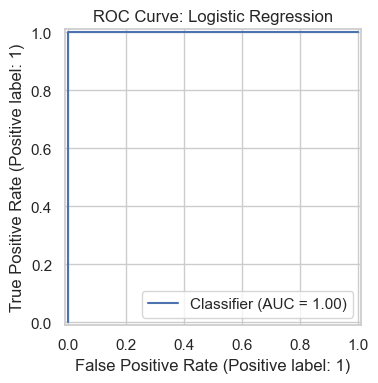

In [13]:
logistic_baseline = Pipeline(make_preprocessing_steps(K_BASELINE) + [
    ("model", LogisticRegression(
        C=1.0,
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        class_weight=CLASS_WEIGHT,
        random_state=RANDOM_STATE,
    )),
])

logistic_baseline_metrics = evaluate_sklearn_model(
    "Logistic Regression",
    logistic_baseline,
    phase="Baseline",
    category="Traditional ML",
)

### 6.2 Ensemble: Random Forest

Random Forest can learn nonlinear decision boundaries and interactions between selected genes. It also provides feature importance values for interpretation.

=== Baseline: Random Forest ===
Accuracy     1.0
Precision    1.0
Recall       1.0
F1-score     1.0
ROC-AUC      1.0
dtype: object

Classification report:
                 precision    recall  f1-score   support

 Healthy/Normal       1.00      1.00      1.00         2
Tumor/Cancerous       1.00      1.00      1.00         9

       accuracy                           1.00        11
      macro avg       1.00      1.00      1.00        11
   weighted avg       1.00      1.00      1.00        11



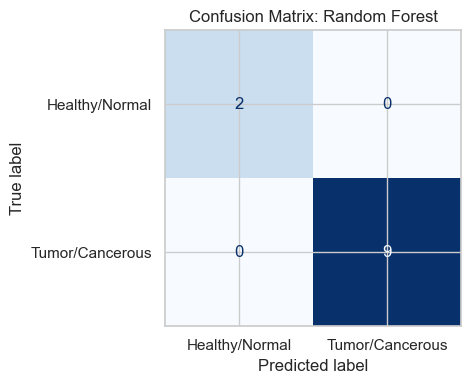

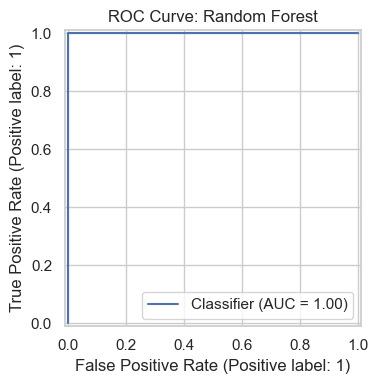

In [14]:
random_forest_baseline = Pipeline(make_preprocessing_steps(K_BASELINE) + [
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt",
        class_weight=CLASS_WEIGHT,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )),
])

random_forest_baseline_metrics = evaluate_sklearn_model(
    "Random Forest",
    random_forest_baseline,
    phase="Baseline",
    category="Ensemble",
)

### 6.3 Deep Learning: Dense Neural Network

Preferred TensorFlow/Keras architecture:

`Input -> Dense(128, relu) -> Dropout -> Dense(64, relu) -> Dropout -> Dense(1, sigmoid)`

It uses binary cross-entropy and early stopping. If TensorFlow is unavailable, `MLPClassifier(hidden_layer_sizes=(128, 64))` is used as a neural-network fallback with L2 regularization and early stopping.

TensorFlow/Keras is not available. Using sklearn MLPClassifier fallback.
TensorFlow import message: ModuleNotFoundError No module named 'tensorflow'


=== Baseline: Neural Network (MLP fallback) ===
Accuracy     1.0
Precision    1.0
Recall       1.0
F1-score     1.0
ROC-AUC      1.0
dtype: object

Classification report:
                 precision    recall  f1-score   support

 Healthy/Normal       1.00      1.00      1.00         2
Tumor/Cancerous       1.00      1.00      1.00         9

       accuracy                           1.00        11
      macro avg       1.00      1.00      1.00        11
   weighted avg       1.00      1.00      1.00        11



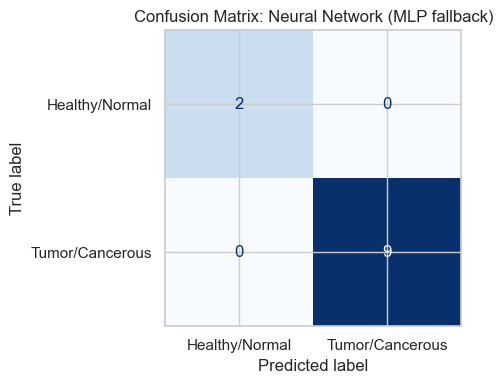

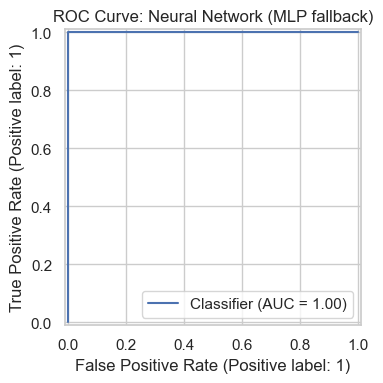

In [15]:
try:
    import tensorflow as tf
    from tensorflow.keras import layers, regularizers
    from sklearn.utils.class_weight import compute_class_weight
    TF_AVAILABLE = True
except Exception as exc:
    TF_AVAILABLE = False
    print("TensorFlow/Keras is not available. Using sklearn MLPClassifier fallback.")
    print("TensorFlow import message:", type(exc).__name__, str(exc))

if TF_AVAILABLE:
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    nn_preprocessor = Pipeline(make_preprocessing_steps(K_BASELINE))
    X_train_nn = nn_preprocessor.fit_transform(X_train, y_train)
    X_test_nn = nn_preprocessor.transform(X_test)
    class_weight_values = compute_class_weight(class_weight="balanced", classes=np.array([0, 1]), y=y_train)
    keras_class_weights = {0: class_weight_values[0], 1: class_weight_values[1]}

    keras_model = tf.keras.Sequential([
        layers.Input(shape=(X_train_nn.shape[1],)),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.30),
        layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.30),
        layers.Dense(1, activation="sigmoid"),
    ])
    keras_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall"), tf.keras.metrics.AUC(name="auc")],
    )
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True)
    history = keras_model.fit(
        X_train_nn,
        y_train,
        validation_split=0.20,
        epochs=200,
        batch_size=8,
        callbacks=[early_stopping],
        class_weight=keras_class_weights,
        verbose=0,
    )
    y_score_nn = keras_model.predict(X_test_nn, verbose=0).ravel()
    y_pred_nn = (y_score_nn >= 0.5).astype(int)
    fitted_models["Dense Neural Network"] = {"preprocessor": nn_preprocessor, "model": keras_model, "history": history}
    neural_network_metrics = show_evaluation("Dense Neural Network", "Baseline", "Deep Learning", y_test, y_pred_nn, y_score_nn)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(history.history["loss"], label="train loss")
    ax.plot(history.history["val_loss"], label="validation loss")
    ax.set_title("Neural Network Training History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Binary cross-entropy")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "keras_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    mlp_fallback = Pipeline(make_preprocessing_steps(K_BASELINE) + [
        ("model", MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.20,
            n_iter_no_change=20,
            random_state=RANDOM_STATE,
        )),
    ])
    neural_network_metrics = evaluate_sklearn_model(
        "Neural Network (MLP fallback)",
        mlp_fallback,
        phase="Baseline",
        category="Deep Learning",
    )

## 7. Baseline Model Comparison

In [16]:
baseline_results_df = (
    pd.DataFrame(all_results)
    .query("Phase == 'Baseline'")
    .sort_values(["F1-score", "ROC-AUC", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)
baseline_results_df.to_csv(TABLES_DIR / "baseline_model_metrics.csv", index=False)
display(baseline_results_df)

,Phase,Category,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline,Traditional ML,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Baseline,Ensemble,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Baseline,Deep Learning,Neural Network (MLP fallback),1.0,1.0,1.0,1.0,1.0


## 8. Model Optimization

Optimization includes hyperparameter tuning, feature selection/ranking, and regularization. Searches use stratified cross-validation and fit preprocessing inside each fold, avoiding test-set leakage.

### 8.1 Logistic Regression Optimization

Best Logistic Regression parameters: {'model__C': 0.01, 'select__k': 50}
Best cross-validation F1-score: 0.9804


,rank_test_score,mean_test_score,std_test_score,param_select__k,param_model__C
0,1,0.980392,0.02773,50,0.01
1,1,0.980392,0.02773,100,0.01
2,1,0.980392,0.02773,500,0.01
3,1,0.980392,0.02773,1000,0.01
4,1,0.980392,0.02773,50,0.10


=== Optimized: Optimized Logistic Regression ===
Accuracy     1.0
Precision    1.0
Recall       1.0
F1-score     1.0
ROC-AUC      1.0
dtype: object

Classification report:
                 precision    recall  f1-score   support

 Healthy/Normal       1.00      1.00      1.00         2
Tumor/Cancerous       1.00      1.00      1.00         9

       accuracy                           1.00        11
      macro avg       1.00      1.00      1.00        11
   weighted avg       1.00      1.00      1.00        11



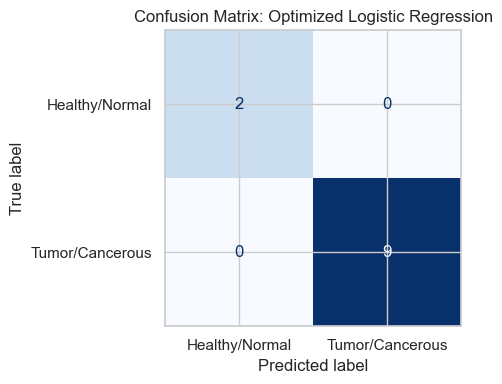

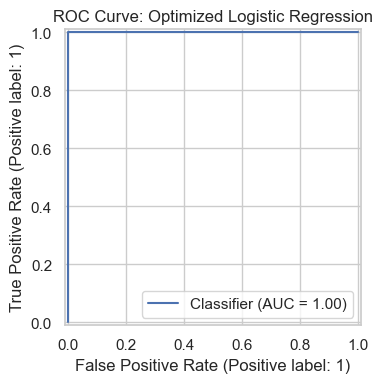

In [17]:
logistic_for_search = Pipeline(make_preprocessing_steps(K_BASELINE) + [
    ("model", LogisticRegression(
        penalty="l2",
        solver="liblinear",
        max_iter=5000,
        class_weight=CLASS_WEIGHT,
        random_state=RANDOM_STATE,
    )),
])

logistic_grid = GridSearchCV(
    estimator=logistic_for_search,
    param_grid={
        "select__k": POSSIBLE_K_VALUES,
        "model__C": [0.01, 0.1, 1.0, 10.0],
    },
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
logistic_grid.fit(X_train, y_train)
logistic_cv_results = pd.DataFrame(logistic_grid.cv_results_).sort_values("rank_test_score")
logistic_cv_results.to_csv(TABLES_DIR / "logistic_grid_search_results.csv", index=False)

print("Best Logistic Regression parameters:", logistic_grid.best_params_)
print("Best cross-validation F1-score:", round(float(logistic_grid.best_score_), 4))
display(logistic_cv_results[["rank_test_score", "mean_test_score", "std_test_score", "param_select__k", "param_model__C"]].head())

optimized_logistic_metrics = evaluate_sklearn_model(
    "Optimized Logistic Regression",
    logistic_grid.best_estimator_,
    phase="Optimized",
    category="Traditional ML",
    already_fit=True,
)

### 8.2 Random Forest Optimization

Best Random Forest parameters: {'select__k': 500, 'model__n_estimators': 200, 'model__min_samples_split': 8, 'model__min_samples_leaf': 4, 'model__max_features': 'sqrt', 'model__max_depth': None}
Best cross-validation F1-score: 1.0


,rank_test_score,mean_test_score,std_test_score,param_select__k,param_model__n_estimators,param_model__max_depth,param_model__min_samples_split,param_model__min_samples_leaf
0,1,1.0,0.0,500,200,None,8,4
1,1,1.0,0.0,1000,100,5,2,1
2,1,1.0,0.0,50,300,10,8,4
3,1,1.0,0.0,500,200,3,4,2
4,1,1.0,0.0,500,300,None,8,4


=== Optimized: Optimized Random Forest ===
Accuracy     1.0
Precision    1.0
Recall       1.0
F1-score     1.0
ROC-AUC      1.0
dtype: object

Classification report:
                 precision    recall  f1-score   support

 Healthy/Normal       1.00      1.00      1.00         2
Tumor/Cancerous       1.00      1.00      1.00         9

       accuracy                           1.00        11
      macro avg       1.00      1.00      1.00        11
   weighted avg       1.00      1.00      1.00        11



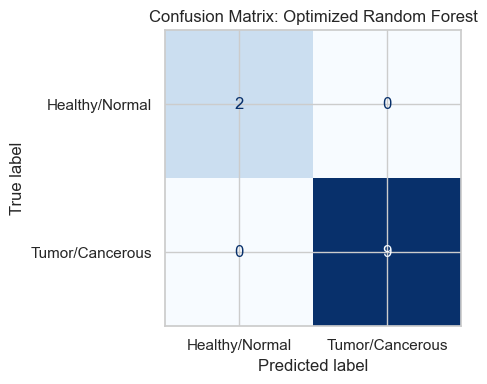

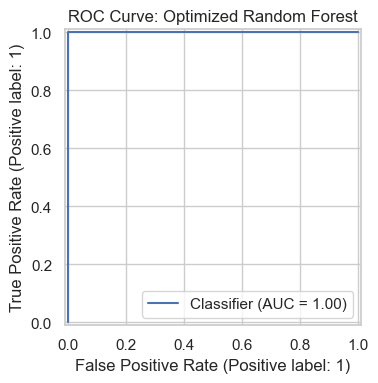

In [18]:
rf_for_search = Pipeline(make_preprocessing_steps(K_BASELINE) + [
    ("model", RandomForestClassifier(class_weight=CLASS_WEIGHT, n_jobs=-1, random_state=RANDOM_STATE)),
])

rf_search = RandomizedSearchCV(
    estimator=rf_for_search,
    param_distributions={
        "select__k": POSSIBLE_K_VALUES,
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 4, 8],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"],
    },
    n_iter=8,
    scoring="f1",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
)
rf_search.fit(X_train, y_train)
rf_cv_results = pd.DataFrame(rf_search.cv_results_).sort_values("rank_test_score")
rf_cv_results.to_csv(TABLES_DIR / "random_forest_search_results.csv", index=False)

print("Best Random Forest parameters:", rf_search.best_params_)
print("Best cross-validation F1-score:", round(float(rf_search.best_score_), 4))
display(rf_cv_results[[
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "param_select__k",
    "param_model__n_estimators",
    "param_model__max_depth",
    "param_model__min_samples_split",
    "param_model__min_samples_leaf",
]].head())

optimized_rf_metrics = evaluate_sklearn_model(
    "Optimized Random Forest",
    rf_search.best_estimator_,
    phase="Optimized",
    category="Ensemble",
    already_fit=True,
)

## 9. Before and After Optimization

The table below compares baseline and optimized results. Improvement is only claimed if the actual metric increased.

In [19]:
metrics_df = pd.DataFrame(all_results)
metrics_df.to_csv(TABLES_DIR / "all_model_metrics.csv", index=False)

def comparison_row(base_name, opt_name):
    base = metrics_df[(metrics_df["Phase"] == "Baseline") & (metrics_df["Model"] == base_name)].iloc[0]
    opt = metrics_df[(metrics_df["Phase"] == "Optimized") & (metrics_df["Model"] == opt_name)].iloc[0]
    return {
        "Model Family": base_name,
        "Baseline F1": base["F1-score"],
        "Optimized F1": opt["F1-score"],
        "F1 Change": opt["F1-score"] - base["F1-score"],
        "Baseline ROC-AUC": base["ROC-AUC"],
        "Optimized ROC-AUC": opt["ROC-AUC"],
        "ROC-AUC Change": opt["ROC-AUC"] - base["ROC-AUC"],
        "Baseline Accuracy": base["Accuracy"],
        "Optimized Accuracy": opt["Accuracy"],
        "Accuracy Change": opt["Accuracy"] - base["Accuracy"],
    }

optimization_comparison_df = pd.DataFrame([
    comparison_row("Logistic Regression", "Optimized Logistic Regression"),
    comparison_row("Random Forest", "Optimized Random Forest"),
])
optimization_comparison_df.to_csv(TABLES_DIR / "baseline_vs_optimized_metrics.csv", index=False)
display(optimization_comparison_df)

for _, row in optimization_comparison_df.iterrows():
    if row["F1 Change"] > 0:
        status = "improved"
    elif row["F1 Change"] < 0:
        status = "decreased"
    else:
        status = "did not change"
    print(f"{row['Model Family']}: F1-score {status} after optimization by {row['F1 Change']:.4f}.")

,Model Family,Baseline F1,Optimized F1,F1 Change,Baseline ROC-AUC,Optimized ROC-AUC,ROC-AUC Change,Baseline Accuracy,Optimized Accuracy,Accuracy Change
0,Logistic Regression,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0
1,Random Forest,1.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0


Logistic Regression: F1-score did not change after optimization by 0.0000.
Random Forest: F1-score did not change after optimization by 0.0000.


## 10. Final Model Comparison

In [20]:
final_results_df = (
    pd.DataFrame(all_results)
    .sort_values(["F1-score", "ROC-AUC", "Accuracy"], ascending=False)
    .reset_index(drop=True)
)
final_results_df.to_csv(TABLES_DIR / "final_model_comparison.csv", index=False)
display(final_results_df)

best_row = final_results_df.iloc[0]
print("Best model by F1-score:", best_row["Model"])
print("Best model phase:", best_row["Phase"])
print("Best F1-score:", round(float(best_row["F1-score"]), 4))
print("Best ROC-AUC:", round(float(best_row["ROC-AUC"]), 4) if not pd.isna(best_row["ROC-AUC"]) else "NA")

,Phase,Category,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Baseline,Traditional ML,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Baseline,Ensemble,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Baseline,Deep Learning,Neural Network (MLP fallback),1.0,1.0,1.0,1.0,1.0
3,Optimized,Traditional ML,Optimized Logistic Regression,1.0,1.0,1.0,1.0,1.0
4,Optimized,Ensemble,Optimized Random Forest,1.0,1.0,1.0,1.0,1.0


Best model by F1-score: Logistic Regression
Best model phase: Baseline
Best F1-score: 1.0
Best ROC-AUC: 1.0


## 11. Feature Ranking and Interpretation

The CSV has no biological gene symbols, so selected features are reported as `gene_0`, `gene_1`, and so on.

,gene,coefficient,absolute_coefficient
28,gene_25823,-0.037508,0.037508
15,gene_20931,-0.037322,0.037322
22,gene_23754,-0.037044,0.037044
25,gene_24850,-0.036933,0.036933
40,gene_35953,-0.036778,0.036778
36,gene_31190,-0.036691,0.036691
20,gene_23230,-0.036601,0.036601
34,gene_30069,-0.036346,0.036346
14,gene_20802,-0.036196,0.036196
48,gene_43153,-0.036129,0.036129


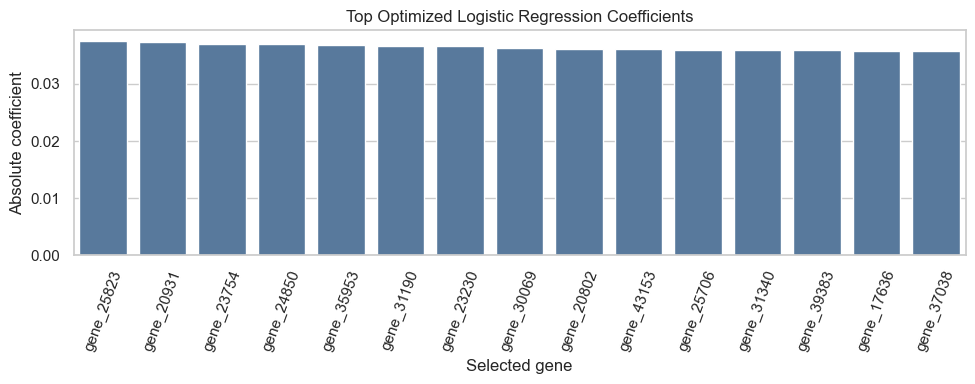

In [21]:
def selected_gene_names_from_pipeline(fitted_pipeline, original_columns):
    variance_step = fitted_pipeline.named_steps["variance"]
    select_step = fitted_pipeline.named_steps["select"]
    after_variance = np.array(original_columns)[variance_step.get_support()]
    return after_variance[select_step.get_support()]


optimized_logistic = fitted_models["Optimized Logistic Regression"]
selected_logistic_genes = selected_gene_names_from_pipeline(optimized_logistic, X_train.columns)
logistic_coefficients = optimized_logistic.named_steps["model"].coef_[0]

logistic_feature_ranking = pd.DataFrame({
    "gene": selected_logistic_genes,
    "coefficient": logistic_coefficients,
    "absolute_coefficient": np.abs(logistic_coefficients),
}).sort_values("absolute_coefficient", ascending=False)
logistic_feature_ranking.to_csv(TABLES_DIR / "optimized_logistic_feature_ranking.csv", index=False)
display(logistic_feature_ranking.head(20))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=logistic_feature_ranking.head(15), x="gene", y="absolute_coefficient", color="#4C78A8", ax=ax)
ax.set_title("Top Optimized Logistic Regression Coefficients")
ax.set_xlabel("Selected gene")
ax.set_ylabel("Absolute coefficient")
ax.tick_params(axis="x", rotation=70)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "optimized_logistic_top_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

,gene,importance
475,gene_40728,0.025
354,gene_24885,0.015
395,gene_30246,0.015
52,gene_2736,0.015
272,gene_16582,0.015
224,gene_12508,0.015
26,gene_1600,0.015
470,gene_39984,0.015
45,gene_2462,0.010
454,gene_37852,0.010


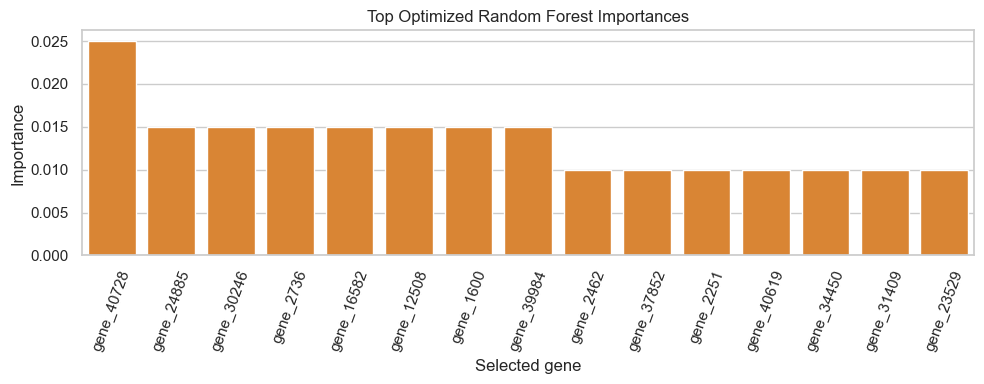

In [22]:
optimized_rf = fitted_models["Optimized Random Forest"]
selected_rf_genes = selected_gene_names_from_pipeline(optimized_rf, X_train.columns)
rf_importance = pd.DataFrame({
    "gene": selected_rf_genes,
    "importance": optimized_rf.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
rf_importance.to_csv(TABLES_DIR / "optimized_random_forest_feature_importance.csv", index=False)
display(rf_importance.head(20))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=rf_importance.head(15), x="gene", y="importance", color="#F58518", ax=ax)
ax.set_title("Top Optimized Random Forest Importances")
ax.set_xlabel("Selected gene")
ax.set_ylabel("Importance")
ax.tick_params(axis="x", rotation=70)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "optimized_random_forest_top_importances.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Final Conclusions

In [23]:
best_row = final_results_df.iloc[0]
best_model_name = best_row["Model"]
best_f1 = best_row["F1-score"]
best_auc = best_row["ROC-AUC"]

lr_change = optimization_comparison_df.loc[
    optimization_comparison_df["Model Family"] == "Logistic Regression", "F1 Change"
].iloc[0]
rf_change = optimization_comparison_df.loc[
    optimization_comparison_df["Model Family"] == "Random Forest", "F1 Change"
].iloc[0]
lr_text = "improved" if lr_change > 0 else "did not improve" if lr_change == 0 else "decreased"
rf_text = "improved" if rf_change > 0 else "did not improve" if rf_change == 0 else "decreased"
auc_text = "NA" if pd.isna(best_auc) else f"{best_auc:.3f}"

display(Markdown(f"""
### Final Conclusions

- **Best model:** {best_model_name}, selected by the final table using F1-score as the primary metric.
- **Best test F1-score:** {best_f1:.3f}; **ROC-AUC:** {auc_text}.
- **Why it performed best:** it gave the strongest precision-recall balance on the held-out test set. Because the test set is small, this result should be interpreted cautiously.
- **Logistic Regression:** strong high-dimensional baseline, regularized, fast, and interpretable, but mostly linear.
- **Random Forest:** can capture nonlinear patterns and gives feature importance, but may overfit small high-dimensional data.
- **Neural Network:** can learn nonlinear relationships, but deep learning is limited by the very small sample size.
- **Effect of feature selection:** reduced the feature space from 43,697 genes to a smaller selected subset, lowering noise and overfitting risk.
- **Optimization result:** Logistic Regression F1-score {lr_text} by {lr_change:.3f}; Random Forest F1-score {rf_text} by {rf_change:.3f}. No improvement is claimed unless the metric increased.
- **Limitations:** only 44 samples, strong feature-to-sample imbalance, class imbalance, no external validation set, and no biological gene symbols.
- **Future work:** collect more samples, validate externally, use repeated stratified cross-validation, add gene symbols, and compare biologically informed feature-selection methods.
"""))


### Final Conclusions

- **Best model:** Logistic Regression, selected by the final table using F1-score as the primary metric.
- **Best test F1-score:** 1.000; **ROC-AUC:** 1.000.
- **Why it performed best:** it gave the strongest precision-recall balance on the held-out test set. Because the test set is small, this result should be interpreted cautiously.
- **Logistic Regression:** strong high-dimensional baseline, regularized, fast, and interpretable, but mostly linear.
- **Random Forest:** can capture nonlinear patterns and gives feature importance, but may overfit small high-dimensional data.
- **Neural Network:** can learn nonlinear relationships, but deep learning is limited by the very small sample size.
- **Effect of feature selection:** reduced the feature space from 43,697 genes to a smaller selected subset, lowering noise and overfitting risk.
- **Optimization result:** Logistic Regression F1-score did not improve by 0.000; Random Forest F1-score did not improve by 0.000. No improvement is claimed unless the metric increased.
- **Limitations:** only 44 samples, strong feature-to-sample imbalance, class imbalance, no external validation set, and no biological gene symbols.
- **Future work:** collect more samples, validate externally, use repeated stratified cross-validation, add gene symbols, and compare biologically informed feature-selection methods.


## 13. Saved Outputs

Important generated tables and figures are saved under:

- `outputs/tables/`
- `outputs/figures/`
